In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import zipfile

from google.colab import files

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# ============================================================
# EXTRACT ZIP FILE
# ============================================================

zip_path = "/content/archive (3).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
# ============================================================
# DATASET PATHS
# ============================================================

train_dir = "/content/train"
test_dir  = "/content/test"

In [67]:
# ============================================================
# VERIFY DATASET STRUCTURE
# ============================================================

# Display emotion class folders
# in training and testing datasets

print("Train Classes:")
print(os.listdir(train_dir))

print("\nTest Classes:")
print(os.listdir(test_dir))

Train Classes:
['fear', 'happy', 'neutral', 'angry', 'disgust', 'sad', 'surprise']

Test Classes:
['fear', 'happy', 'neutral', 'angry', 'disgust', 'sad', 'surprise']


In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

# Define image size and batch size
IMG_SIZE = (48,48)
BATCH_SIZE = 64

# Load training dataset
# Images are resized to 48x48 grayscale
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

# Load testing dataset
# Images are resized to 48x48 grayscale
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [8]:
# ============================================================
# DATASET INFORMATION
# ============================================================

# Get emotion class names from the dataset
class_names = train_ds.class_names

# Display the total number of emotion classes
print("Number of Classes:", len(class_names))

# Display all emotion class names
print("Classes:", class_names)

Number of Classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
# ============================================================
# CLASS NAMES
# ============================================================

# Get emotion class names from the dataset
class_names = train_ds.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


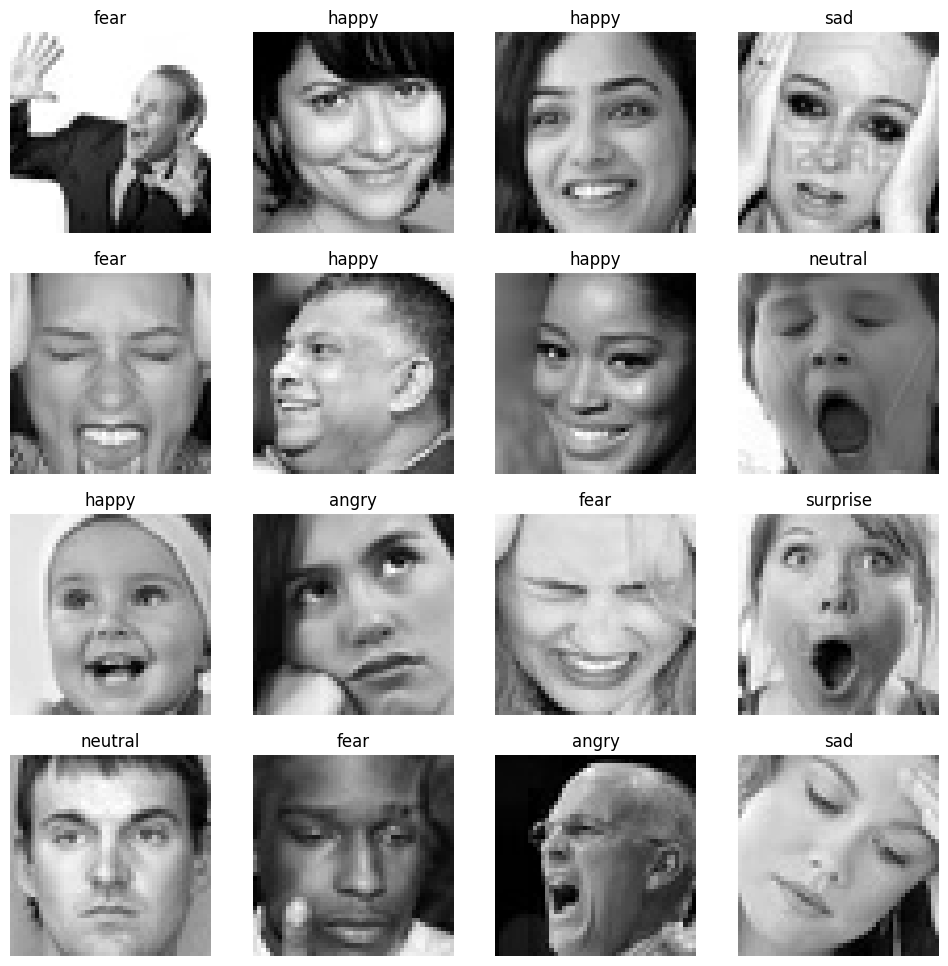

In [10]:
# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [11]:
# ============================================================
# DATA AUGMENTATION
# ============================================================

# Apply random transformations to training images
# to improve model generalization
data_augmentation = keras.Sequential([

    # Randomly flip images horizontally
    layers.RandomFlip("horizontal"),

    # Randomly rotate images
    layers.RandomRotation(0.1),

    # Randomly zoom images
    layers.RandomZoom(0.1)

])

In [12]:
# ============================================================
# MODEL 1 - BASIC CNN
# ============================================================

# Build a basic CNN model for emotion recognition
cnn_model = keras.Sequential([

    # Apply data augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # First Convolution Block
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    # Second Convolution Block
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    # Third Convolution Block
    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    # Convert feature maps into a feature vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128,activation='relu'),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer for 7 emotion classes
    layers.Dense(7,activation='softmax')
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# TRAIN BASIC CNN
# ============================================================

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.2573 - loss: 1.7896 - val_accuracy: 0.3068 - val_loss: 1.7038
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3219 - loss: 1.6938 - val_accuracy: 0.4043 - val_loss: 1.5250
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3861 - loss: 1.5716 - val_accuracy: 0.4581 - val_loss: 1.4225
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4237 - loss: 1.4994 - val_accuracy: 0.4781 - val_loss: 1.3624
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4442 - loss: 1.4439 - val_accuracy: 0.4929 - val_loss: 1.3169
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4617 - loss: 1.4102 - val_accuracy: 0.4836 - val_loss: 1.3428
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4687 - loss: 1.3809 - val_accuracy: 0.5118 - val_loss: 1.2690
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4802 - loss: 1.3653 - val_acc

In [14]:
# ============================================================
# MODEL 2 - DEEP CNN
# ============================================================

# Build a Deep CNN model for emotion recognition
deep_cnn = keras.Sequential([

    # Apply data augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # First Convolution Block
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Second Convolution Block
    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Third Convolution Block
    layers.Conv2D(256,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fourth Convolution Block
    layers.Conv2D(512,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Convert feature maps to a feature vector
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layer
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),

    # Fully Connected Layer
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    # Output layer for 7 emotion classes
    layers.Dense(7,activation='softmax')
])

# Compile the model
deep_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
deep_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,949,447 (7.44 MB)

 Trainable params: 1,947,527 (7.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
# ============================================================
# TRAIN DEEP CNN
# ============================================================

history_deep = deep_cnn.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.2361 - loss: 1.8636 - val_accuracy: 0.2471 - val_loss: 2.0311
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.3059 - loss: 1.7062 - val_accuracy: 0.3143 - val_loss: 1.7403
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.3728 - loss: 1.5932 - val_accuracy: 0.4439 - val_loss: 1.4475
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4068 - loss: 1.5195 - val_accuracy: 0.4570 - val_loss: 1.4146
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.4316 - loss: 1.4631 - val_accuracy: 0.4884 - val_loss: 1.3744
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4484 - loss: 1.4258 - val_accuracy: 0.5131 - val_loss: 1.2777
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4614 - loss: 1.3961 - val_accuracy: 0.5159 - val_loss: 1.2570
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4710 - loss: 1.3770 - 

In [16]:
# ============================================================
# CONVERT GRAYSCALE TO RGB
# ============================================================

# Convert grayscale images to RGB
# for MobileNetV2 input requirements
def gray_to_rgb(image, label):

    image = tf.image.grayscale_to_rgb(image)

    return image, label

# Apply conversion to training dataset
train_rgb = train_ds.map(gray_to_rgb)

# Apply conversion to testing dataset
test_rgb = test_ds.map(gray_to_rgb)

In [65]:
# ============================================================
# MODEL 3 - MOBILENETV2
# ============================================================

# Load pretrained MobileNetV2 model
# without the final classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(48,48,3)
)

# Freeze pretrained layers
# to use MobileNetV2 as a feature extractor
base_model.trainable = False

# Build the MobileNetV2 emotion classifier
mobilenet_model = keras.Sequential([

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Extract image features
    base_model,

    # Convert feature maps to a feature vector
    layers.GlobalAveragePooling2D(),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer for 7 emotion classes
    layers.Dense(7,activation='softmax')
])

# Compile the model
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
mobilenet_model.summary()

/tmp/ipykernel_2474/1093055289.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [66]:
# ============================================================
# TRAIN MOBILENETV2
# ============================================================

history_mobile = mobilenet_model.fit(
    train_rgb,
    validation_data=test_rgb,
    epochs=15
)

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.2820 - loss: 1.9920 - val_accuracy: 0.3670 - val_loss: 1.6300
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3377 - loss: 1.7091 - val_accuracy: 0.3739 - val_loss: 1.6178
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3428 - loss: 1.6784 - val_accuracy: 0.3782 - val_loss: 1.6012
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3471 - loss: 1.6702 - val_accuracy: 0.3759 - val_loss: 1.6101
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3464 - loss: 1.6639 - val_accuracy: 0.3753 - val_loss: 1.5987
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3552 - loss: 1.6584 - val_accuracy: 0.3734 - val_loss: 1.6054
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3545 - loss: 1.6590 - val_accuracy: 0.3764 - val_loss: 1.6118
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3487 - loss: 1.6634 - val_acc

CNN Accuracy: 56.78461790084839
Deep CNN Accuracy: 59.15296673774719
MobileNetV2 Accuracy: 37.837839126586914


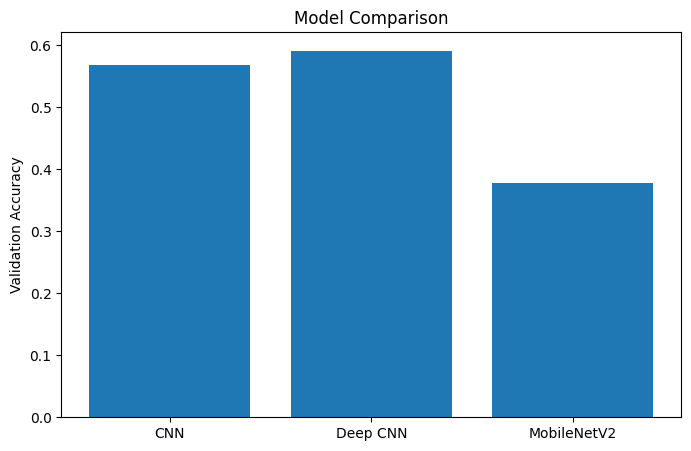

In [69]:
# ============================================================
# MODEL COMPARISON
# ============================================================

cnn_acc = max(history_cnn.history['val_accuracy'])
deep_acc = max(history_deep.history['val_accuracy'])
mobile_acc = max(history_mobile.history['val_accuracy'])

print("CNN Accuracy:", cnn_acc*100)
print("Deep CNN Accuracy:", deep_acc*100)
print("MobileNetV2 Accuracy:", mobile_acc*100)

plt.figure(figsize=(8,5))

plt.bar(
    ["CNN","Deep CNN","MobileNetV2"],
    [cnn_acc,deep_acc,mobile_acc]
)

plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.show()

In [70]:
# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================

import pandas as pd

# Create a table containing validation
# accuracy of all trained models
results = pd.DataFrame({
    "Model": ["CNN", "Deep CNN", "MobileNetV2"],
    "Validation Accuracy": [
        cnn_acc,
        deep_acc,
        mobile_acc
    ]
})

# Display the comparison table
print(results)

         Model  Validation Accuracy
0          CNN             0.567846
1     Deep CNN             0.591530
2  MobileNetV2             0.378378


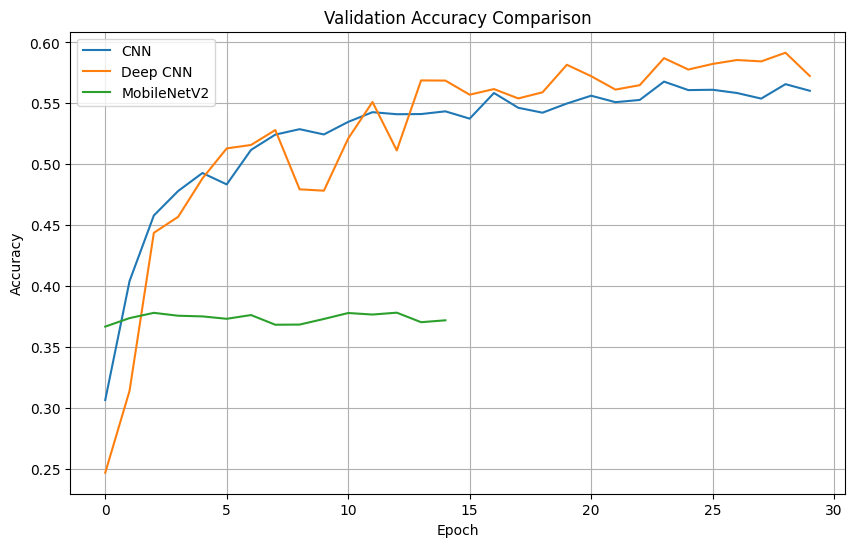

In [71]:
# ============================================================
# ACCURACY COMPARISON OF ALL MODELS
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    history_deep.history['val_accuracy'],
    label='Deep CNN'
)

plt.plot(
    history_mobile.history['val_accuracy'],
    label='MobileNetV2'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

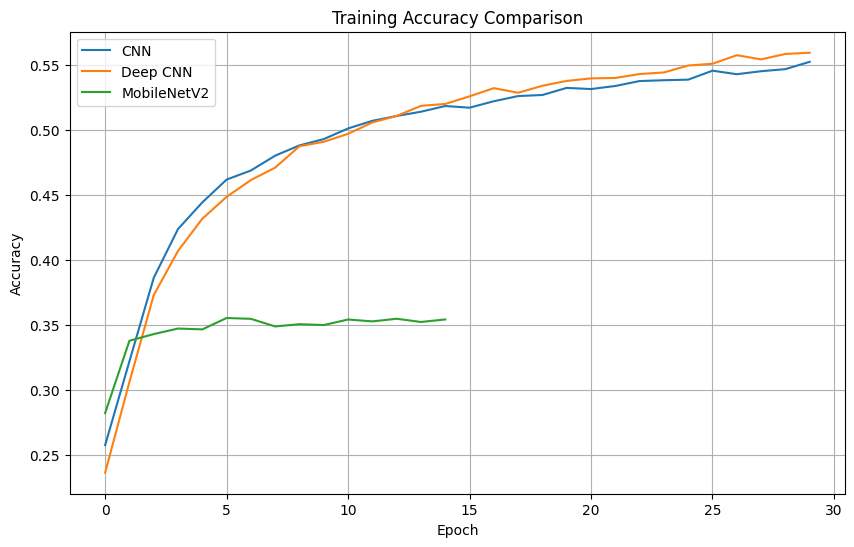

In [72]:
# ============================================================
# TRAINING ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    history_cnn.history['accuracy'],
    label='CNN'
)

plt.plot(
    history_deep.history['accuracy'],
    label='Deep CNN'
)

plt.plot(
    history_mobile.history['accuracy'],
    label='MobileNetV2'
)

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [161]:
# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

Saving DMUbjq2UjJcG3umGv3Qjjd.jpeg to DMUbjq2UjJcG3umGv3Qjjd (2).jpeg


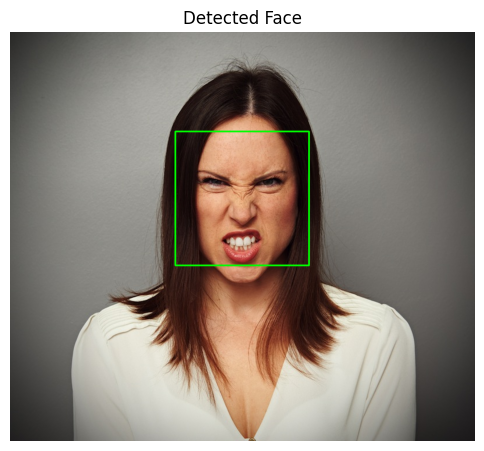

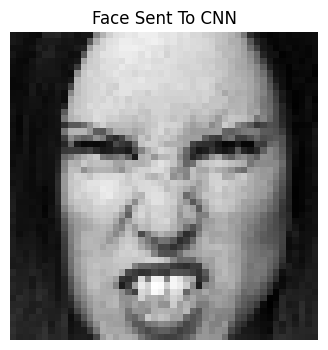

Input Shape: (1, 48, 48, 1)


In [162]:
# ============================================================
# FACE DETECTION + PREPROCESSING
# ============================================================

image_path = list(uploaded.keys())[0]

# Read Image
img = cv2.imread(image_path)

# Convert to RGB for Display
img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# Convert to Grayscale for Face Detection
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# Load Face Detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# Detect Faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30,30)
)

# Check if Face Found
if len(faces) == 0:

    print("❌ No Face Detected")

else:

    # Take First Face
    x, y, w, h = faces[0]

    # Draw Rectangle Around Face
    cv2.rectangle(
        img_rgb,
        (x, y),
        (x+w, y+h),
        (0,255,0),
        2
    )

    # Crop Face
    face_gray = gray[y:y+h, x:x+w]

    # Resize to FER Input Size
    face_gray = cv2.resize(
        face_gray,
        (48,48)
    )

    # Show Original Image
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title("Detected Face")
    plt.axis("off")
    plt.show()

    # Show Face Sent To Model
    plt.figure(figsize=(4,4))
    plt.imshow(face_gray, cmap="gray")
    plt.title("Face Sent To CNN")
    plt.axis("off")
    plt.show()

    # IMPORTANT:
    # Do NOT divide by 255 here
    # Model already contains Rescaling(1./255)

    cnn_input = np.expand_dims(
        face_gray,
        axis=(0,-1)
    ).astype("float32")

    print("Input Shape:", cnn_input.shape)

In [163]:
# ============================================================
# CNN PREDICTION
# ============================================================

# Predict emotion probabilities using the CNN model
cnn_prediction = cnn_model.predict(cnn_input)

# Get the class with highest probability
cnn_class = np.argmax(cnn_prediction)

# Convert class index to emotion label
cnn_emotion = class_names[cnn_class]

# Get prediction confidence percentage
cnn_confidence = np.max(cnn_prediction) * 100

# Display prediction results
print("CNN Prediction")
print("Emotion:", cnn_emotion)
print("Confidence:", f"{cnn_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
CNN Prediction
Emotion: angry
Confidence: 84.92%


In [164]:
prediction = cnn_model.predict(cnn_input)

for emotion, prob in zip(class_names, prediction[0]):
    print(f"{emotion}: {prob*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
angry: 84.92%
disgust: 5.12%
fear: 9.73%
happy: 0.03%
neutral: 0.01%
sad: 0.16%
surprise: 0.02%


In [165]:
# ============================================================
# DEEP CNN PREDICTION
# ============================================================

# Predict emotion probabilities using the Deep CNN model
deep_prediction = deep_cnn.predict(cnn_input)

# Get the class with highest probability
deep_class = np.argmax(deep_prediction)

# Convert class index to emotion label
deep_emotion = class_names[deep_class]

# Get prediction confidence percentage
deep_confidence = np.max(deep_prediction) * 100

# Display prediction results
print("\nDeep CNN Prediction")
print("Emotion:", deep_emotion)
print("Confidence:", f"{deep_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Deep CNN Prediction
Emotion: angry
Confidence: 92.38%


In [166]:
# ============================================================
# MOBILENETV2 PREDICTION
# ============================================================

# Convert grayscale face image to RGB
# MobileNetV2 requires 3-channel input
mobile_face = cv2.cvtColor(
    face_gray.astype(np.float32),
    cv2.COLOR_GRAY2RGB
)

# Add batch dimension for model prediction
mobile_input = np.expand_dims(
    mobile_face,
    axis=0
)

# Predict emotion probabilities using MobileNetV2
mobile_prediction = mobilenet_model.predict(
    mobile_input
)

# Get the class with highest probability
mobile_class = np.argmax(
    mobile_prediction
)

# Convert class index to emotion label
mobile_emotion = class_names[
    mobile_class
]

# Get prediction confidence percentage
mobile_confidence = np.max(
    mobile_prediction
) * 100

# Display prediction results
print("\nMobileNetV2 Prediction")
print("Emotion:", mobile_emotion)
print("Confidence:", f"{mobile_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

MobileNetV2 Prediction
Emotion: neutral
Confidence: 23.82%


In [167]:
# ============================================================
# COMPARISON TABLE
# ============================================================

print("\n")
print("="*50)
print("EMOTION PREDICTION COMPARISON")
print("="*50)

print(f"CNN          : {cnn_emotion:10s} {cnn_confidence:.2f}%")

print(f"Deep CNN     : {deep_emotion:10s} {deep_confidence:.2f}%")

print(f"MobileNetV2  : {mobile_emotion:10s} {mobile_confidence:.2f}%")



EMOTION PREDICTION COMPARISON
CNN          : angry      84.92%
Deep CNN     : angry      92.38%
MobileNetV2  : neutral    23.82%


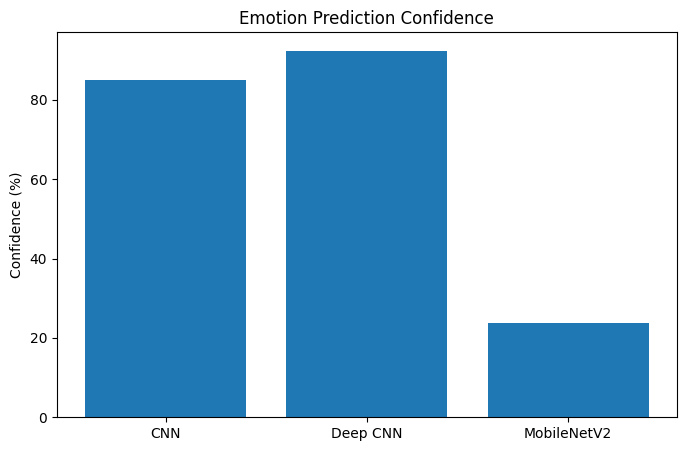

In [168]:
# ============================================================
# CONFIDENCE GRAPH
# ============================================================

models = [
    "CNN",
    "Deep CNN",
    "MobileNetV2"
]

confidences = [
    cnn_confidence,
    deep_confidence,
    mobile_confidence
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    confidences
)

plt.ylabel("Confidence (%)")

plt.title(
    "Emotion Prediction Confidence"
)

plt.show()